# Chapter 8. Unsupervised Learning Techniques

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.datasets import make_blobs, load_digits
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression

***Clustering***: the goal is to group similar instances together into clusters. Clustering is a great tool for data analysis, customer segmentation, recommender systems, search engines, image segmentation, semi-supervised learning, dimensionality reduction, and more.
<br>

***Anomaly detection (aka outlier detection)***: the goal is to learn what "normal" data looks like, and then use that to detect abnormal instances. These instances are called *anomalies* or *outliers*, while the normal instances are called *inliers*. Anomaly detection is useful in a wide variety of applications, such as fraud detection, detecting defective products in manufacturing, identifying new trends in time series, or removing outliers from a dataset before training another model, which can significantly improve the performance of the resulting model.
<br>

***Density estimation***: the goal is to estimate the *probability density function (PDF)* of the random process that generated the dataset. Density estimation is commonly used for anomaly detection: instances located in very low-density regions are likely to be anomalies. It is also useful for data analysis and visualization.

## 1. Clustering Algorithms: k-means and DBSCAN

### 1.1. k-Means Clustering

#### 1.1.1. The k-means algorithm

***K-Means Clustering*** starts by placing the centroids randomly (e.g., by picking k instances at random from the dataset and using their locations as centroids). Then label the instances by assigning each to the cluster whose centroid is closest -> update the centroid by computing the mean of the instances in each cluster -> label the instance -> update the centroid -> so on -> untill the centroids stop moving. The algorithm is guaranteed to converge in a finite number of steps (usually quite small), because the mean squared distance between the instances and their closest centroids can only go down at each step, and since it cannot be negative, it is guaranteed to converge.

<br>

Though guaranteed to converge, it may not converge to the right solution: whether it does or not depends on the **centroid initialization**.

It is important to **scale the input features before running k-means**, or the clusters may be very stretches and k-means will perform poorly. Scaling the features does not guarantee that all the clusters will be nice and spherical, but it generally helps k-means.

The computational complexity of the algorithm is generally linear with regard to 
- the number of instances m,
- the number of clusters k,
- the number of dimensions n.
<br>

However, this is only true with the data has a clustering structure. If it does not, then in the worst-case scenario, the complexity can increase exponentially with the number of instances. In practice, this rarely happens, and k-means is generally one of the fatest clustering algorithms.

In [2]:
blob_centers = np.array(
    [[0.2, 2.3], [-1.5, 2.3], [-2.8, 1.8], [-2.8, 2.8], [-2.8, 1.3]]
)
blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])
X, y = make_blobs(
    n_samples=2000, centers=blob_centers, cluster_std=blob_std, random_state=7
)

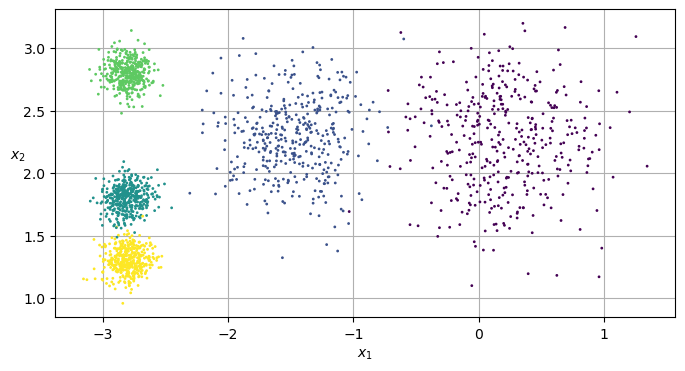

In [3]:
def plot_clusters(X, y):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$", rotation=0)


plt.figure(figsize=(8, 4))
plot_clusters(X, y)
plt.gca().set_axisbelow(True)
plt.grid()

plt.show()

**Note, we have to specify the number of clusters k that the algorithm must find.**

In [4]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=43)
y_pred = kmeans.fit_predict(X)

In [5]:
np.unique(y_pred)

array([0, 1, 2, 3, 4], dtype=int32)

In [6]:
kmeans.cluster_centers_.round(2)

array([[-2.8 ,  1.8 ],
       [ 0.21,  2.26],
       [-2.79,  2.8 ],
       [-1.47,  2.29],
       [-2.8 ,  1.3 ]])

We can easily assign new instances to the cluster whose centroid is closet:

In [7]:
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
kmeans.predict(X_new)

array([1, 1, 2, 2], dtype=int32)

K-means works well when clusters are roughly spherical, similar in size, and well separated. **It performs poorly when clusters have very different diameters** because it assigns each point based only on the distance to the nearest centroid.

Instead of assigning each instance to a single cluster, which is called ***hard clustering***, it can be useful to give each instance a score per cluster, which is called ***soft clustering***. The score can be the distance between the instance and the centroid or a similarity score (or affinity), such as the Gaussian radial basis function.
- Can be a very efficient nonlinear dimensionality reduction technique if we have a high dimensional data.
- We can also use these distances as extra features to train another model.

In [8]:
kmeans.transform(X_new).round(2)

array([[2.81, 0.33, 2.9 , 1.49, 2.89],
       [5.81, 2.8 , 5.85, 4.48, 5.84],
       [1.21, 3.29, 0.29, 1.69, 1.71],
       [0.73, 3.22, 0.36, 1.55, 1.22]])

#### 1.1.2. Centroid initialization methods

One option is to run the algorithm multiple times with different random initializations and keep the best solution.
- `n_init` hyperparameter: the number of random initialization
- `init = 'random'`
<br>

The model's ***intertia***: the performance metric determines the best solution.
$$
\text{inertia} = \sum_i \left\| x^{(i)} - c^{(i)} \right\|^2
$$

In [9]:
kmeans.inertia_

211.5985372581684

The `score()` method resturns to the negative inertia (it is negative because a predictor's `score()` method must always respect Scikit-Learn's "greater is better" rule – if a predictor is better than another, its `score()` methods should return a greater score)

In [10]:
kmeans.score(X)

-211.5985372581684

***K-means++***: `int='k-means++` (default hyperparameter) is a smarter initialization step that tends to **select centroids that are distant from one another**, which makes the k-means algorithm much more likely to locate all important clusters, and less likely to converge to a suboptimal solution.

1. Take one centroid $c^{(1)}$, chosen uniformly at random from the dataset.

2. Take a new centroid $c^{(i)}$, choosing an instance $x^{(i)}$ with probability:

$$
\frac{D(x^{(i)})^2}{\sum_{j=1}^{m} D(x^{(j)})^2}
$$

where $D(x^{(i)})$ is the distance between the instance $x^{(i)}$ and the closest centroid that was already chosen.

This probability distribution ensures that instances farther away from already chosen centroids are much more likely to be selected as centroids.

3. Repeat the previous step until all $k$ centroids have been chosen.

When setting `init = 'k-means++'`, the `KMeans` class actually uses a variant of k-means++ called *greedy k-means++*: instead of sampling a single centroid at each iteration, it samples multiple and picks the best one. When using this algorithm, `n_init` defaults to 1.

#### 1.1.3. Mini-batch k-means

Instead of using the full dataset at each iteration, the algorithm uses mini-batches, moving the centroids just slightly at each iteration. This speeds up the algorithm and makes it possible to cluster huge datasets that do not fit in memory.

In [11]:
minibatch_kmeans = MiniBatchKMeans(n_clusters=5, random_state=32)
# minibatch_kmeans.fit(X)

#### 1.1.4. Finding the optimal number of clusters Based on Silhouette Score

The inertia is not a good performance metric when trying to choose k (i.e., the number of clusters) because it keeps getting lower as we increase k.

***Silhouette score***, which is the mean silhouette coefficient over all the instances. An instance's silhouette coefficient is equal to `(b-a)/max(a, b)`, where a is the mean distance to the other instances in the same cluster (i.e., the mean intra-cluster distance) and b is the mean nearest-cluster distance (i.e., the mean distance to the instances of the next closet cluster). 
- The silhouette coefficient varys between -1 and +1.
- A coefficient close to +1 mean that the instance is well inside its own cluster and far from other clusters.
- A coefficient close to 0 means that it is close to a cluster boundary.
- A coefficient close to -1 means that the instance may have been assigned to the wrong cluster.

In [12]:
silhouette_score(X, kmeans.labels_)

np.float64(0.6555176425728279)

In [13]:
results = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=32)
    kmeans.fit(X)

    results.append(
        {
            "k": k,
            "inertia": kmeans.inertia_,
            "silhouette_score": silhouette_score(X, kmeans.labels_),
        }
    )

df_results = pd.DataFrame(results)
df_results

,k,inertia,silhouette_score
0,2,1149.891350,0.595363
1,3,653.216719,0.572390
2,4,261.796778,0.688532
3,5,219.463742,0.634959
4,6,197.104469,0.579511
5,7,179.889203,0.584588
6,8,118.619455,0.561620
7,9,107.992795,0.556062
8,10,103.463638,0.549594


In [14]:
df_results.shape

(9, 3)

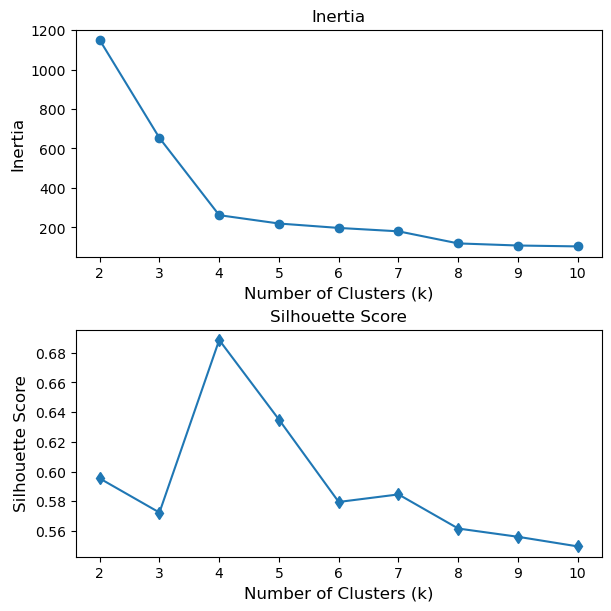

In [15]:
fig, axes = plt.subplots(
    nrows=df_results.shape[1] - 1, ncols=1, figsize=(6, 6), constrained_layout=True
)

axes[0].plot(df_results["k"], df_results["inertia"], marker="o")
axes[0].set_title("Inertia", fontsize=12)
axes[0].set_xlabel("Number of Clusters (k)", fontsize=12)
axes[0].set_ylabel("Inertia", fontsize=12)

axes[1].plot(df_results["k"], df_results["silhouette_score"], marker="d")
axes[1].set_title("Silhouette Score", fontsize=12)
axes[1].set_xlabel("Number of Clusters (k)", fontsize=12)
axes[1].set_ylabel("Silhouette Score", fontsize=12)

plt.show()


The above figures confirmed that K = 4 is a very good choice.

### 1.2. Limits of k-Means

1. Run the algorithm several times to avoid suboptimal solutions.
2. Need to specify the number of clusters.
3. K-means does not behave very well when the clusters have varying sizes, different densities, or nonspherical shapes.

### 1.3. Using Clustering for Image Segmentation

### 1.4. Using Clustering for Semi-Supervised Learning

When we have plenty of unlabeled instances and very few labeled instances. Clustering can help choose which additional instances to label (e.g., near the cluster centroids). It can also be used to propogate the most common label in each cluster to the unlabeled instances in that cluster.

In [16]:
X_digits, y_digits = load_digits(return_X_y=True) # 1,797 grayscale 8 × 8 images representing the digits 0 to 9
X_train, y_train = X_digits[:1400], y_digits[:1400]
X_test, y_test = X_digits[1400:], y_digits[1400:]

Assume we only had 50 **randomly** labeled instances in training set

In [17]:
n_labeled = 50
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train[:n_labeled], y_train[:n_labeled])
log_reg.score(X_test, y_test)

0.7581863979848866

Instead of relying on randomly labeled instances, we can **label instances which are representative** and then train our classification model based on those representative instances, which may improve our model performance. 
<br> 

To do so, we first performed clustering to find the instances that were closest to the centroids. Then we used these instances as the training set and trained the logistic regression model. We found that the accuracy increased by ~10%! Note, we still only trained on 50 instances.


In [18]:
k = 50
kmeans = KMeans(n_clusters=k, random_state=32)
X_dist = kmeans.fit_transform(X_train) # Generate the distance from each instance to each cluster center
X_train_representative = X_train[X_dist.argmin(axis=0)] # Find the closest instance to each cluster center
y_train_representative = y_train[X_dist.argmin(axis=0)] # Find the labels of the closest instances

In [19]:
log_reg.fit(X_train_representative, y_train_representative)
log_reg.score(X_test, y_test)

0.8513853904282116

Furthermore, we can convert this task from semi-supervised learning into supervised learning by **propagating the labels to all other instances within the same cluster** and using all instances, rather than just 50, to train the model.


In [20]:
y_train_propogated = np.empty(X_train.shape[0], dtype=np.int32)
for i in range(k):
    y_train_propogated[kmeans.labels_ == i] = y_train_representative[i]
log_reg.fit(X_train, y_train_propogated)
log_reg.score(X_test, y_test)


0.8664987405541562

Moreover, we can further remove outliers within each cluster and train model based on the refined dataset, which may also improve the model's performance.

In [24]:
percentile_cut = 80
x_cluster_dist = X_dist[np.arange(X_dist.shape[0]), kmeans.labels_]
retain_flag = np.zeros(X_train.shape[0], dtype=bool)
for i in range(k):
    in_cluster = (kmeans.labels_ == i)
    retain_flag[in_cluster] = x_cluster_dist[in_cluster] < np.percentile(x_cluster_dist[in_cluster], percentile_cut)

X_train_removeoutliers = X_train[retain_flag]
y_train_removeoutliers = y_train[retain_flag]
log_reg.fit(X_train_removeoutliers, y_train_removeoutliers)
log_reg.score(X_test, y_test)

0.9118387909319899

***Active learning***: To continue improving our model, we can further do a few rounds of active learning, which is when a **hunan expert interacts with the learning algorithm, providing labels for specific instances when the algorihthm requests them**
1. The model is trained on the labeled instance gathered so far, and this model is used to make predictions on all the unlabeled instances.
2. The instances for which the model is most uncertain (i.e., where its estimated probability is lowest) are given to the expert for labeling.
3. We iterate this process until the performance improvement stops being worth the labeling effort.
<br>

Other active learning strategy include labeling the instances that would result in the largest model change or the largest drop in the model's validation error, or the instances that different models disagree on.

### 1.5. DBSCAN

### 1.6. Other Clustering Algorithms

## 2. Gaussian Mixtures